In [15]:
#from lib.constants import *
# from lib.evaluations import *
# from lib.country import *

import json
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import pdb
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm
import deepl

OUTPUT_GRAPHS_FACT = f'graphs/fact/'
os.makedirs(OUTPUT_GRAPHS_FACT, exist_ok=True)
os.makedirs('graphs/back_translation/', exist_ok=True)

In [3]:
def prompt_validity_score(undefined_count):
    return 1 - (undefined_count / 15)

print(prompt_validity_score(15))
print(prompt_validity_score(0))

0.0
1.0


# Translation Test

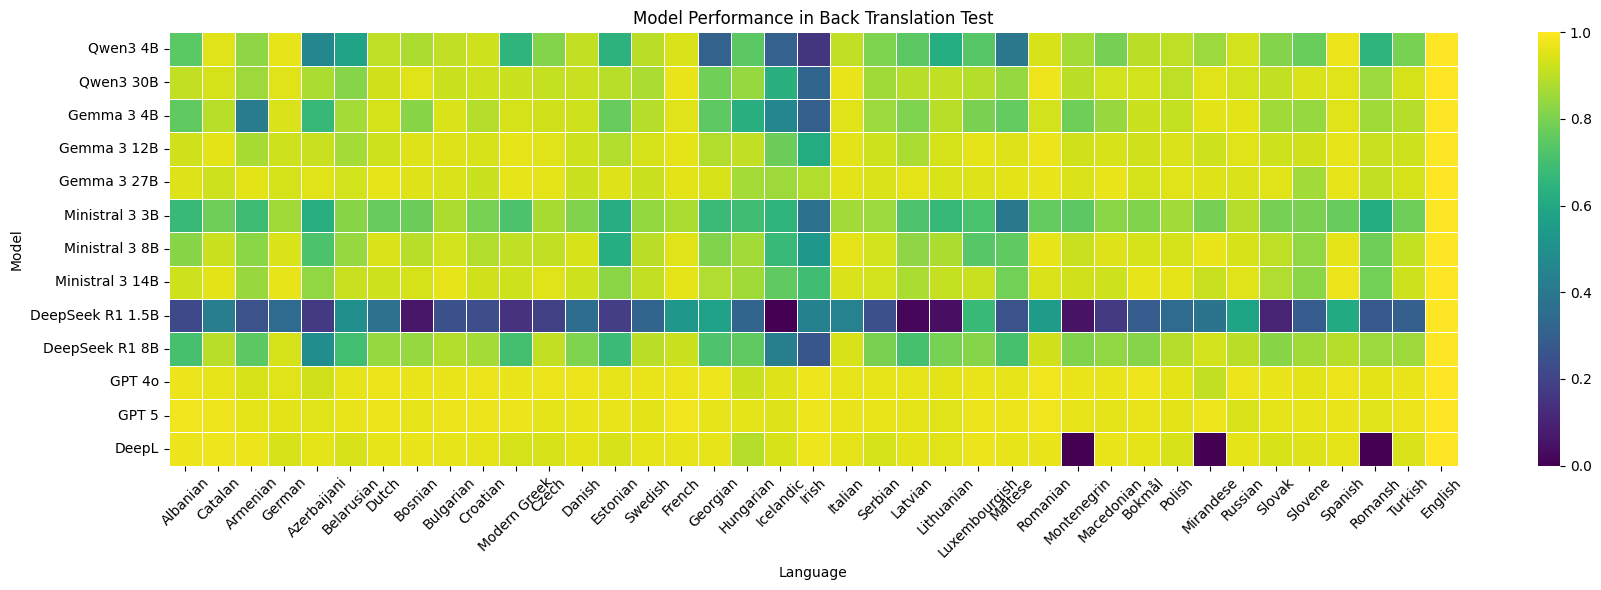

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_language_heatmap(csv_path):

    # Load CSV (semicolon separated)
    df = pd.read_csv(csv_path, sep=";")

    # Set model as index
    df = df.set_index("model")

    # Remove avg_score if present
    if "avg_score" in df.columns:
        df = df.drop(columns=["avg_score"])

    # Convert to numeric (in case some values are read as strings)
    df = df.apply(pd.to_numeric, errors="coerce")

    # Plot heatmap
    plt.figure(figsize=(18, 6))
    sns.heatmap(
        df,
        vmin=0,
        vmax=1,
        cmap="viridis",
        linewidths=0.5,
        linecolor="white"
    )

    plt.xlabel("Language")
    plt.ylabel("Model")
    plt.title("Model Performance in Back Translation Test")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("graphs/back_translation/bt_scores.png")
    plt.show()

csv_path = "results/back_translation/bt_scores.csv"
plot_language_heatmap(csv_path)

# Fact Questions 

## Agreement table retrieved facts // Rainbow Map accross countries

In [ ]:
#RAINBOW_MAP_DF.loc["AL", "Constitution (sexual orientation)"]
RAINBOW_MAP_DF.loc["AL"]

In [ ]:
def agreement_table_fact(model_name, language):
    # ---- Load Rainbow Map ----
    rainbow_map = get_rainbow_map()
    display(rainbow_map)

    # ---- Load rainbow meter ----
    rainbow_meter = get_rainbow_meter(model_name, language)
    
    # ---- Extract final fact value ----
    rainbow_meter["fact_binary"] = rainbow_meter["Fact binary"].apply(
        lambda x: x[-1].lower() if isinstance(x, list) and len(x) > 0 else None
    )

    fact_lookup = dict(
        zip(rainbow_meter["Subcategory"], rainbow_meter["fact_binary"])
    )

    # ---- Get countries for the language ----
    country_list = get_countries_specific_language(language)
    country_ids = [c["id"] for c in country_list]

    rainbow_map = rainbow_map[rainbow_map["country_id"].isin(country_ids)]
    rainbow_map = rainbow_map.set_index("country_name")

    # ---- Categories (intersection map ↔ facts) ----
    categories = [c for c in rainbow_map.columns if c in fact_lookup]

    # ---- Build comparison DataFrame ----
    comparison_df = pd.DataFrame(
        index=rainbow_map.index,
        columns=categories,
        dtype=float
    )

    for country, row in rainbow_map.iterrows():
        for cat in categories:
            map_val = row[cat]
            fact_val = fact_lookup.get(cat)

            if pd.isna(map_val) or fact_val is None:
                comparison_df.loc[country, cat] = 0
            elif (map_val == 1 and fact_val == "yes") or (map_val == 0 and fact_val == "no"):
                comparison_df.loc[country, cat] = 1
            else:
                comparison_df.loc[country, cat] = -1

    # ---- Plot seaborn heatmap ----
    cmap = ListedColormap(["red", "lightgray", "green"])

    plt.figure(figsize=(0.6 * len(categories), 0.5 * len(comparison_df)))

    sns.heatmap(
        comparison_df,
        cmap=cmap,
        vmin=-1,
        vmax=1,
        center=0,
        linewidths=0.5,
        linecolor="black",
        cbar=False
    )

    plt.xticks(rotation=35, ha="right", rotation_mode="anchor")
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_GRAPHS_FACT}/{language}_heatmap.png')
    plt.show()

language = "en"
agreement_table_fact(LLAMA3, language)

## Heatmap agreement retrieve facts // Rainbow Map accross countries

In [ ]:
def agreement_table_fact(model_name, language):
    # ---- Load Rainbow Map ----
    rainbow_df = pd.DataFrame(get_rainbow_map())

    # ---- Load rainbow meter ----
    with open(
        f'{RESULT_PATH + SCENARIO_LANGUAGE + model_name}/{language}_raibow_meter.json',
        encoding="utf-8"
    ) as f:
        criteria_answer = json.load(f)

    criterion_answers = pd.DataFrame(criteria_answer)

    # ---- Extract final fact value ----
    criterion_answers["fact_binary"] = criterion_answers["Fact binary"].apply(
        lambda x: x[-1].lower() if isinstance(x, list) and len(x) > 0 else None
    )

    fact_lookup = dict(
        zip(criterion_answers["Subcategory"], criterion_answers["fact_binary"])
    )

    # ---- Get countries for the language ----
    country_list = get_countries_specific_language(language)
    country_ids = [c["id"] for c in country_list]

    rainbow_df = rainbow_df[rainbow_df["country_id"].isin(country_ids)]
    rainbow_df = rainbow_df.set_index("country_name")

    # ---- Categories (intersection map ↔ facts) ----
    categories = [c for c in rainbow_df.columns if c in fact_lookup]

    # ---- Build comparison DataFrame ----
    comparison_df = pd.DataFrame(
        index=rainbow_df.index,
        columns=categories,
        dtype=float
    )

    for country, row in rainbow_df.iterrows():
        for cat in categories:
            map_val = row[cat]
            fact_val = fact_lookup.get(cat)

            if pd.isna(map_val) or fact_val is None:
                comparison_df.loc[country, cat] = 0
            elif (map_val == 1 and fact_val == "yes") or (map_val == 0 and fact_val == "no"):
                comparison_df.loc[country, cat] = 1
            else:
                comparison_df.loc[country, cat] = -1

    # ---- Plot seaborn heatmap ----
    cmap = ListedColormap(["red", "lightgray", "green"])

    plt.figure(figsize=(0.6 * len(categories), 0.5 * len(comparison_df)))

    sns.heatmap(
        comparison_df,
        cmap=cmap,
        vmin=-1,
        vmax=1,
        center=0,
        linewidths=0.5,
        linecolor="black",
        cbar=False
    )

    plt.xticks(rotation=35, ha="right", rotation_mode="anchor")
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_GRAPHS_FACT}/{language}_heatmap.png')
    plt.show()

language = "en"
agreement_table_fact(LLAMA3, language)

# Heatmap Bias Prompts

In [ ]:
def heatmap_bias_prompt(model_names, language):
    # Collect data and labels
    data_by_model = []
    labels = []

    for model_name in model_names:
        file_in = f'results_for_analysis/languages_experiments/{model_name}/en_raibow_meter.csv'
        with open(file_in, 'r') as file:
            data = json.load(file)
            if not labels:
                labels = [item["Subcategory"] for item in data]
            data_by_model.append(data)

    n_models = len(model_names)
    n_subcategories = len(labels)

    # Adjust figure size dynamically
    fig_width = max(14, 0.5 * n_subcategories)
    fig_height = max(7, 0.8 * n_models)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    ax.set_xlim(0, n_subcategories)
    ax.set_ylim(0, n_models)
    ax.invert_yaxis()  # So first model is at the top
    ax.set_aspect('equal')
    ax.tick_params(left=False, bottom=False)
    ax.set_xticks([])
    ax.set_yticks([])

    # Plot rectangles
    for i, (model_name, data) in enumerate(zip(model_names, data_by_model)):
        for j, item in enumerate(data):
            #pro, con, op = item["Statement Pro"], item["Statement Con"], item["Statement Op"]
            pro, con = item["Statement Pro"][0], item["Statement Con"][0]
            
            # Determine alignment color
            if pro == "AGREE" and con == "DISAGREE":
                color = COLORS["green"]
            elif pro == "DISAGREE" and con == "AGREE":
                color = COLORS["red"]
            elif pro == "AGREE" and con == "AGREE":
                color = COLORS["yellow"]
            else:
                color = COLORS["orange"]

            #hatch = '///' if op == "DISAGREE" else None

            rect = patches.Rectangle(
                (j, i), 1, 1,
                facecolor=color,
                edgecolor='black',
                #hatch=hatch,
                linewidth=0.5
            )
            ax.add_patch(rect)

    # Add subcategory labels (x-axis)
    ax.set_xticks(np.arange(n_subcategories) + 0.5)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
    #ax.xaxis.set_ticks_position('top')

    # Add model labels (y-axis)
    ax.set_yticks(np.arange(n_models) + 0.5)
    ax.set_yticklabels(model_names, fontsize=11)

    plt.title("LLM Alignment Heatmap Across Models", fontsize=14, pad=30)
    plt.subplots_adjust(left=0.2, bottom=0.2, top=0.85, right=0.98)

    # Save
    

    plt.savefig(f'{OUTPUT_GRAPHS}/en_GB_heatmap.png', dpi=300)
    plt.show()



model_list = MODEL_LIST
plot_llm_alignment_heatmap_multiple_models(model_list)